# Modeling Notebook

This notebook loads the engineered features and trains/evaluates machine learning models for credit risk prediction.

In [1]:
# 1. Setup and imports
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

# Ensure local source takes precedence
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

from b2b_credit_risk_analysis.modeling.train import train_model, save_model

sns.set(style="whitegrid")

In [2]:
# 2. Load features
feature_path = "data/processed/features/customer_feature_dataset.csv"
features = pd.read_csv(project_root / feature_path)

print(f"Loaded features: {features.shape}")
print(features.head())
print(features['has_default'].value_counts())

Loaded features: (10000, 8)
   customer_key  total_exposure  total_overdue  avg_utilization  max_overdue  \
0             1    5.098456e+08   1.062024e+08         0.694239   4833970.35   
1             2    9.325729e+08   1.026136e+08         0.452623   4016365.14   
2             3    3.460612e+06   4.316011e+05         0.435602     24508.37   
3             4    2.246920e+06   5.028745e+05         1.213359     18808.46   
4             5    2.650903e+07   3.794258e+06         1.091009    220576.70   

   monthly_obs  overdue_rate  has_default  
0           33      0.208303            1  
1           48      0.110033            0  
2           41      0.124718            1  
3           41      0.223806            1  
4           34      0.143131            1  
has_default
1    8011
0    1989
Name: count, dtype: int64


Model training complete
ROC AUC: 0.9056
Accuracy: 0.8560


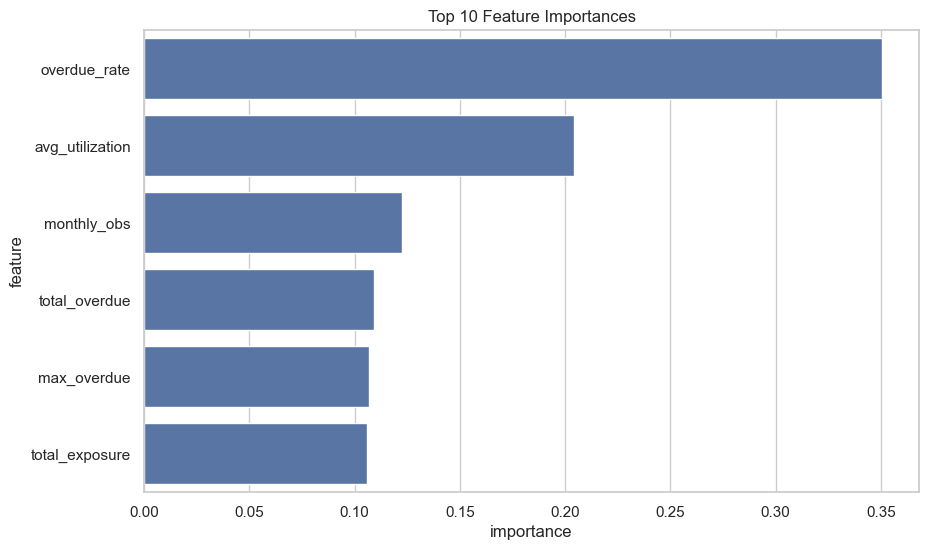

In [5]:
# 3. Train model
training = train_model(features, target_col="has_default")

model = training["model"]
metrics = training["metrics"]

print("Model training complete")
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print(f"Accuracy: {metrics['classification_report']['accuracy']:.4f}")

# Feature importance
feature_cols = [col for col in features.columns if col not in ['customer_key', 'has_default']]
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.show()

              precision    recall  f1-score   support

           0       0.66      0.57      0.61       497
           1       0.90      0.93      0.91      2003

    accuracy                           0.86      2500
   macro avg       0.78      0.75      0.76      2500
weighted avg       0.85      0.86      0.85      2500

ROC AUC: 0.9056


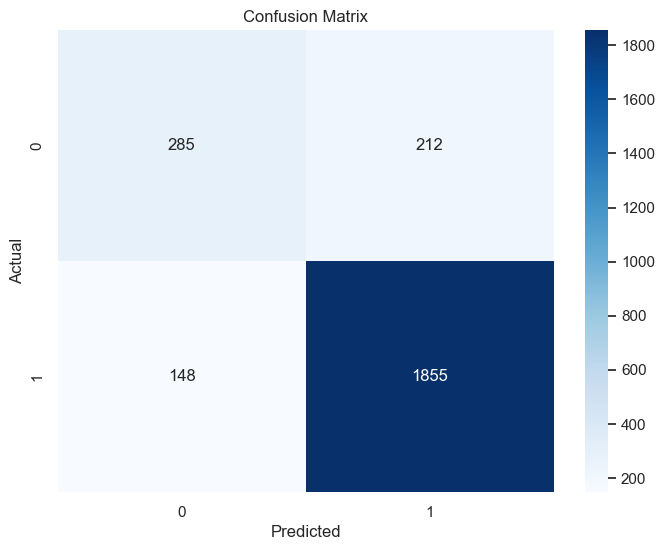

In [6]:
# 4. Detailed evaluation
X_test = training["X_test"]
y_test = training["y_test"]
y_pred = training["y_pred"]
y_proba = training["y_proba"]

print(classification_report(y_test, y_pred))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba):.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [7]:
# 5. Save model
model_path = project_root / "models" / "rf_default_model.pkl"
save_model(model, model_path)
print(f"Model saved to {model_path}")

Model saved to /Users/huseyn/Documents/GitHub/b2b_credit_risk_analysis/models/rf_default_model.pkl
